# Object Tracking

Environment Install
```
pip install opencv-python opencv-contrib-python numpy torch torchvision matplotlib scikit-image filterpy
```

## Feature Extract

### 1. Color histogram
A global feature counting pixel color distribution of an image region. Robust to rotation and occlusion, used for object color matching and tracking.
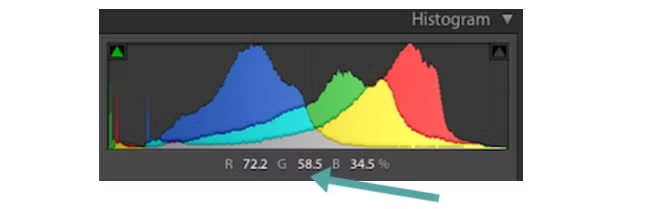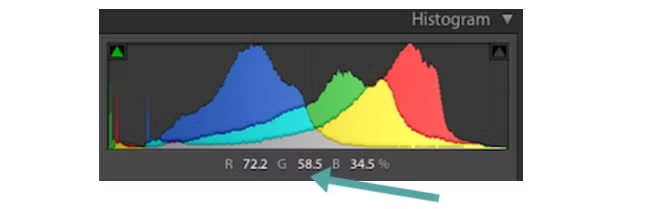

### 2. HOG
A local gradient-based feature that extracts edge and contour information by computing gradient orientation histograms. Insensitive to lighting, ideal for shape description and object tracking.
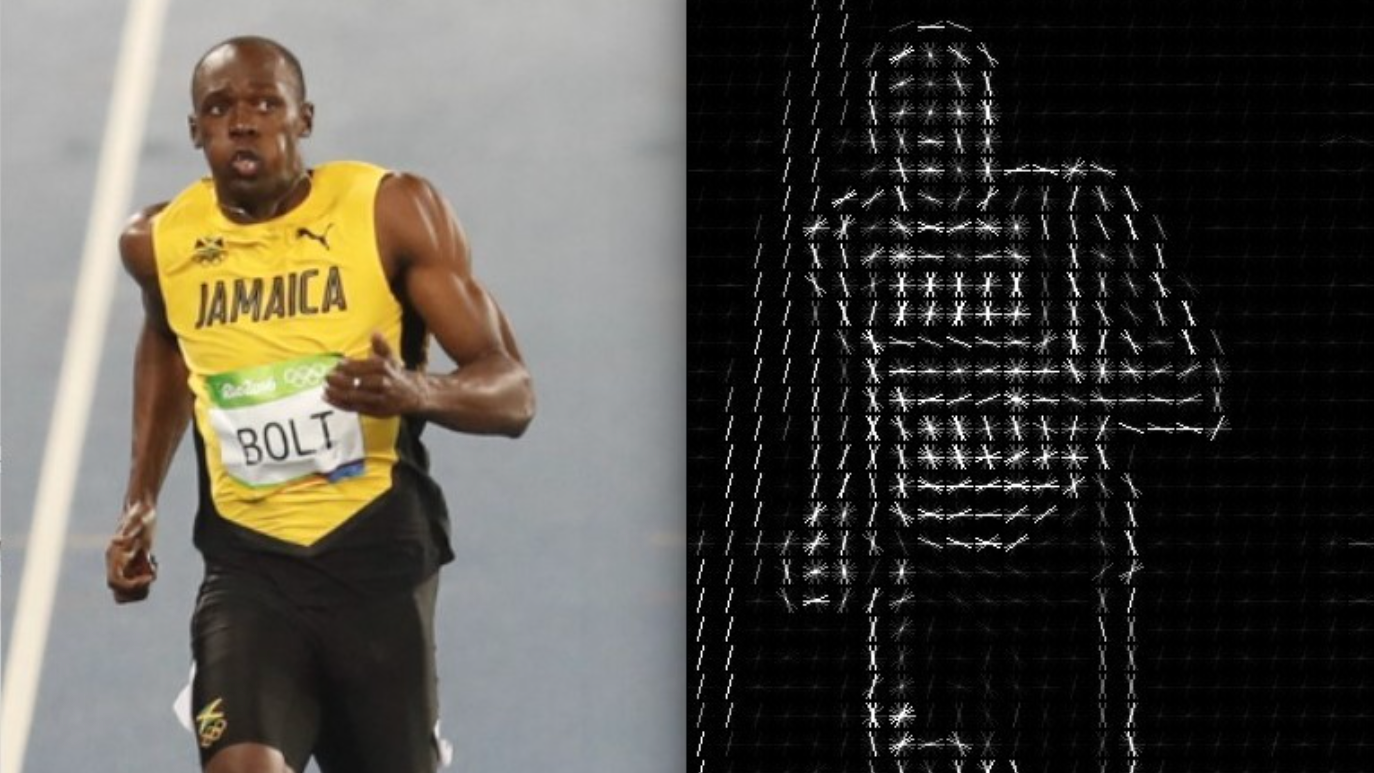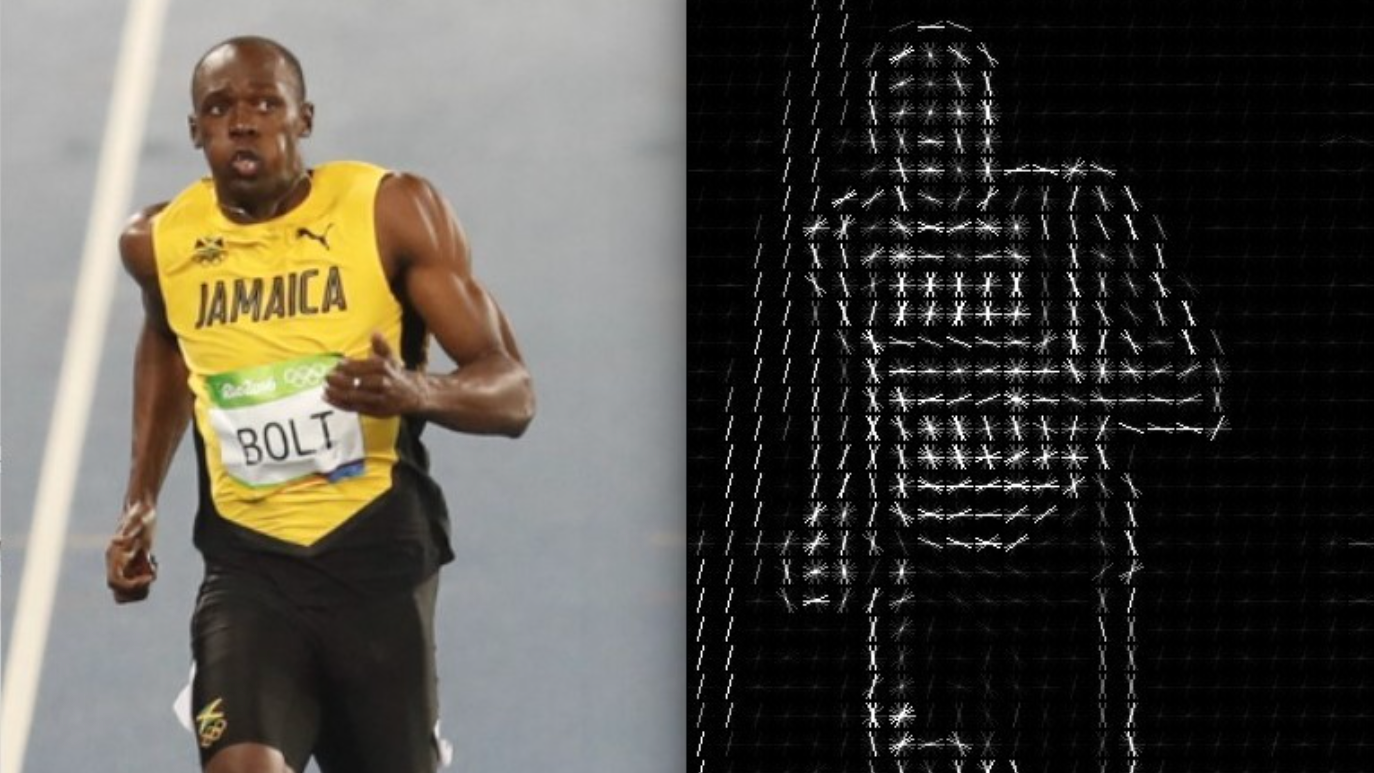

### 3. Depth feature
Reflects 3D spatial structure and distance of targets from depth data. Separates overlapping or similar-color objects to enhance tracking robustness.
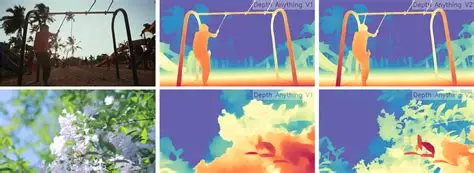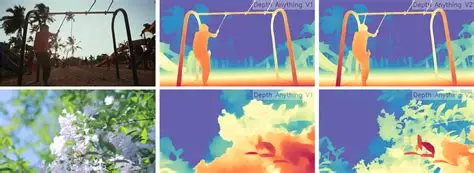


Feature Extraction & Comparison

COLOR_HISTOGRAM Features:
  Red vs Green: 0.2879
  Red vs Blue: 0.2879
  Red vs Yellow: 0.2879
  Red vs Purple: 0.2879
  Green vs Blue: 0.2879
  Green vs Yellow: 0.2879
  Green vs Purple: 0.2879
  Blue vs Yellow: 0.2879
  Blue vs Purple: 0.2879
  Yellow vs Purple: 0.2879

HOG Features:
  Red vs Green: 0.9931
  Red vs Blue: 0.9960
  Red vs Yellow: 0.9829
  Red vs Purple: 0.9978
  Green vs Blue: 0.9938
  Green vs Yellow: 0.9795
  Green vs Purple: 0.9910
  Blue vs Yellow: 0.9840
  Blue vs Purple: 0.9960
  Yellow vs Purple: 0.9861

CNN Features:
  Red vs Green: 0.9187
  Red vs Blue: 0.9506
  Red vs Yellow: 0.8569
  Red vs Purple: 0.9212
  Green vs Blue: 0.9429
  Green vs Yellow: 0.8555
  Green vs Purple: 0.9263
  Blue vs Yellow: 0.8401
  Blue vs Purple: 0.9092
  Yellow vs Purple: 0.8686


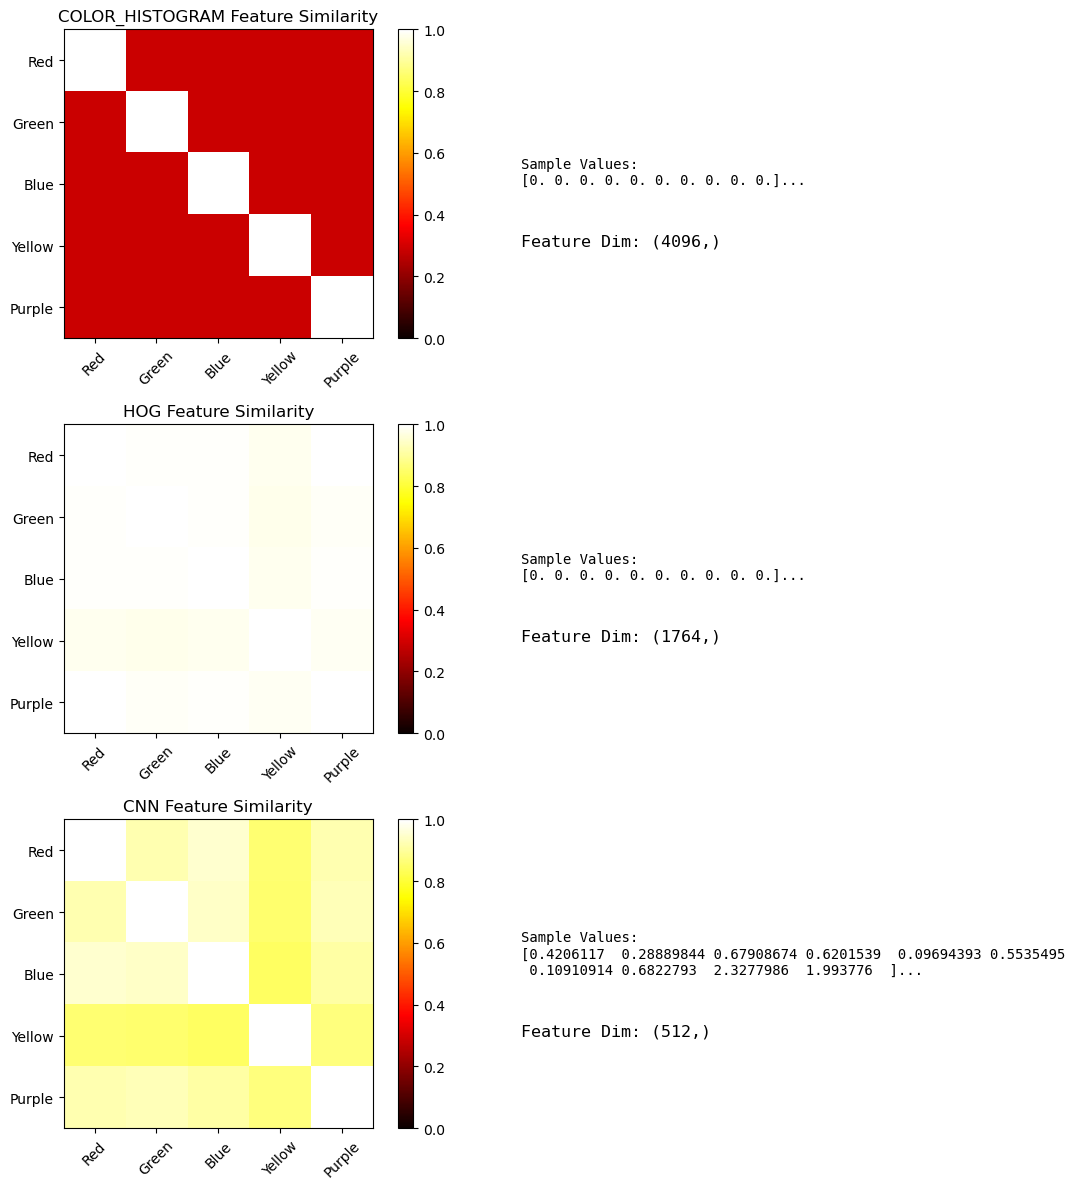


Conclusion:
  - Color Histogram: Sensitive to color, good for colored objects
  - HOG: Sensitive to shape/edges, good for object shape
  - CNN: Strongest representation, high computation for complex scenes


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import color
import torch
import torchvision.models as models
import warnings
warnings.filterwarnings('ignore')

class FeatureExtractor:
    """Feature extractor for object tracking"""
    
    def __init__(self, method='color_histogram'):
        """
        Args:
            method: 'color_histogram', 'hog', 'cnn'
        """
        self.method = method
        
        # Load pretrained model for CNN features
        if method == 'cnn':
            self.model = models.resnet18(pretrained=True)
            self.model = torch.nn.Sequential(*list(self.model.children())[:-1])
            self.model.eval()
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.model.to(self.device)
    
    def extract_color_histogram(self, image, bins=(16, 16, 16)):
        """Extract color histogram features"""
        # Convert to HSV space (more robust to illumination)
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        return hist
    
    def extract_hog_features(self, image):
        """Extract HOG features"""
        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Resize to fixed size
        resized = cv2.resize(gray, (64, 64))
        features, _ = hog(resized, pixels_per_cell=(8, 8), 
                          cells_per_block=(2, 2), visualize=True)
        return features
    
    def extract_cnn_features(self, image):
        """Extract deep CNN features"""
        # Preprocess
        resized = cv2.resize(image, (224, 224))
        # BGR to RGB, normalize
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(img_rgb).float().permute(2, 0, 1).unsqueeze(0)
        img_tensor = img_tensor / 255.0
        # Standardization (ImageNet stats)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        img_tensor = (img_tensor - mean) / std
        img_tensor = img_tensor.to(self.device)
        
        with torch.no_grad():
            features = self.model(img_tensor)
        return features.squeeze().cpu().numpy()
    
    def extract(self, image):
        """Main feature extraction interface"""
        if self.method == 'color_histogram':
            return self.extract_color_histogram(image)
        elif self.method == 'hog':
            return self.extract_hog_features(image)
        elif self.method == 'cnn':
            return self.extract_cnn_features(image)
        else:
            raise ValueError(f"Unknown method: {self.method}")
    
    def similarity(self, feat1, feat2):
        """Compute similarity between two features"""
        if self.method == 'color_histogram':
            # Histogram correlation
            return cv2.compareHist(feat1.astype(np.float32), 
                                   feat2.astype(np.float32), 
                                   cv2.HISTCMP_CORREL)
        else:
            # Cosine similarity
            return np.dot(feat1, feat2) / (np.linalg.norm(feat1) * np.linalg.norm(feat2) + 1e-8)


def compare_features_on_balls():
    """Compare feature performance on colored balls"""
    
    # Generate features for balls with different colors
    colors = ['Red', 'Green', 'Blue', 'Yellow', 'Purple']
    color_bgr = {
        'Red': (0, 0, 255),
        'Green': (0, 255, 0),
        'Blue': (255, 0, 0),
        'Yellow': (0, 255, 255),
        'Purple': (255, 0, 255)
    }
    
    # Create synthetic ball image
    def create_ball_image(color_bgr, size=(50, 50)):
        img = np.ones((size[0], size[1], 3), dtype=np.uint8) * 255
        center = (size[0]//2, size[1]//2)
        radius = size[0]//2 - 2
        cv2.circle(img, center, radius, color_bgr, -1)
        # Add illumination variation
        cv2.circle(img, center, radius//2, 
                   (min(255, color_bgr[0]+50), min(255, color_bgr[1]+50), min(255, color_bgr[2]+50)), 
                   -1)
        return img
    
    print("=" * 60)
    print("Feature Extraction & Comparison")
    print("=" * 60)
    
    # Generate ball images
    ball_images = {color: create_ball_image(bgr) for color, bgr in color_bgr.items()}
    
    # Compare three feature methods
    methods = ['color_histogram', 'hog', 'cnn']
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    
    for idx, method in enumerate(methods):
        extractor = FeatureExtractor(method=method)
        
        # Extract features
        features = {}
        for color, img in ball_images.items():
            features[color] = extractor.extract(img)
        
        # Compute similarity matrix
        colors_list = list(colors)
        sim_matrix = np.zeros((len(colors), len(colors)))
        
        for i, c1 in enumerate(colors_list):
            for j, c2 in enumerate(colors_list):
                sim_matrix[i, j] = extractor.similarity(features[c1], features[c2])
        
        # Plot similarity heatmap
        ax = axes[idx, 0]
        im = ax.imshow(sim_matrix, cmap='hot', vmin=0, vmax=1)
        ax.set_xticks(range(len(colors)))
        ax.set_yticks(range(len(colors)))
        ax.set_xticklabels(colors_list, rotation=45)
        ax.set_yticklabels(colors_list)
        ax.set_title(f'{method.upper()} Feature Similarity')
        
        # Show feature dimension
        ax_text = axes[idx, 1]
        ax_text.axis('off')
        sample_feat = features[colors_list[0]]
        feat_shape = sample_feat.shape if hasattr(sample_feat, 'shape') else len(sample_feat)
        ax_text.text(0.1, 0.3, f'Feature Dim: {feat_shape}', fontsize=12, family='monospace')
        ax_text.text(0.1, 0.5, f'Sample Values:\n{sample_feat[:10]}...', fontsize=10, family='monospace')
        
        plt.colorbar(im, ax=ax)
        
        # Print results
        print(f"\n{method.upper()} Features:")
        for i, c1 in enumerate(colors_list):
            for j, c2 in enumerate(colors_list):
                if i < j:
                    print(f"  {c1} vs {c2}: {sim_matrix[i, j]:.4f}")
    
    plt.tight_layout()
    plt.savefig('feature_comparison.png', dpi=150)
    plt.show()
    
    print("\n" + "=" * 60)
    print("Conclusion:")
    print("  - Color Histogram: Sensitive to color, good for colored objects")
    print("  - HOG: Sensitive to shape/edges, good for object shape")
    print("  - CNN: Strongest representation, high computation for complex scenes")
    print("=" * 60)
    
    return ball_images


if __name__ == "__main__":
    ball_images = compare_features_on_balls()

## The classic object tracking process (Kalman filtering + color feature)

```
Program Start
  ↓
run_classic_tracker()
  ↓
Define HSV color ranges → Initialize ColorBasedTracker
  ↓
Load/Generate video → Read frames sequentially
  ↓
Per frame: detect_balls to detect colored balls
  ↓
Predict positions for existing tracks using Kalman Filter
  ↓
Greedy algorithm matching: Predictions ↔ Detections
  ↓
Matched: Update Kalman filter, trajectory, bbox
Unmatched detection: Create new target track
Unmatched track: Increase lost counter, delete if timeout
  ↓
Draw bounding boxes, trajectories, IDs, legend
  ↓
Write output video + Display window
  ↓
Loop until video ends
```


In [2]:
import cv2
import numpy as np
from collections import deque
import os

class KalmanFilterSimple:
    """Simple Kalman Filter implementation using OpenCV KalmanFilter"""
    
    def __init__(self):
        self.kf = cv2.KalmanFilter(4, 2)
        
        dt = 1.0
        self.kf.transitionMatrix = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ], dtype=np.float32)
        
        self.kf.measurementMatrix = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ], dtype=np.float32)
        
        self.kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.05
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.5
        self.kf.errorCovPost = np.eye(4, dtype=np.float32) * 1
        self.kf.statePost = np.zeros((4, 1), dtype=np.float32)
        
    def predict(self):
        prediction = self.kf.predict()
        x = float(prediction[0, 0]) if prediction.shape == (4, 1) else float(prediction[0])
        y = float(prediction[1, 0]) if prediction.shape == (4, 1) else float(prediction[1])
        return x, y
    
    def update(self, x, y):
        measurement = np.array([[np.float32(x)], [np.float32(y)]])
        self.kf.correct(measurement)
    
    def get_position(self):
        x = float(self.kf.statePost[0, 0])
        y = float(self.kf.statePost[1, 0])
        return x, y


class ColorBasedTracker:
    """Classic tracker based on color features"""
    
    def __init__(self, color_ranges, max_trails=50, lost_threshold=30):
        self.color_ranges = color_ranges
        self.kalman_filters = {}
        self.trajectories = {}
        self.lost_counters = {}
        self.next_id = 0
        self.max_trails = max_trails
        self.lost_threshold = lost_threshold
        self.target_colors = {}
        self.target_bboxes = {}  # Store bounding boxes for each target
        
    def detect_balls(self, frame):
        """Detect balls in the frame"""
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        all_detections = []
        
        for color_name, (lower, upper) in self.color_ranges.items():
            mask = cv2.inRange(hsv, lower, upper)
            kernel = np.ones((5, 5), np.uint8)
            mask = cv2.erode(mask, kernel, iterations=1)
            mask = cv2.dilate(mask, kernel, iterations=2)
            
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                area = cv2.contourArea(contour)
                if 100 < area < 5000:
                    x, y, w, h = cv2.boundingRect(contour)
                    center = (x + w//2, y + h//2)
                    
                    perimeter = cv2.arcLength(contour, True)
                    if perimeter > 0:
                        circularity = 4 * np.pi * area / (perimeter * perimeter)
                        if circularity > 0.5:
                            all_detections.append({
                                'bbox': (x, y, w, h),
                                'center': center,
                                'area': area,
                                'color': color_name,
                                'circularity': circularity
                            })
        
        return all_detections
    
    def greedy_matching(self, predictions, detections, max_dist=100):
        """Greedy algorithm to match predictions and detections"""
        matches = []
        used_predictions = set()
        used_detections = set()
        
        pred_list = list(predictions.items())
        
        while True:
            min_dist = float('inf')
            min_i, min_j = -1, -1
            
            for i, (track_id, pred_pos) in enumerate(pred_list):
                if i in used_predictions:
                    continue
                for j, det in enumerate(detections):
                    if j in used_detections:
                        continue
                    dist = np.sqrt((pred_pos[0] - det['center'][0])**2 + 
                                   (pred_pos[1] - det['center'][1])**2)
                    if dist < min_dist:
                        min_dist = dist
                        min_i, min_j = i, j
            
            if min_i >= 0 and min_j >= 0 and min_dist <= max_dist:
                track_id = pred_list[min_i][0]
                matches.append((track_id, min_j, min_dist))
                used_predictions.add(min_i)
                used_detections.add(min_j)
            else:
                break
        
        return matches
    
    def update(self, frame):
        """Update tracking results"""
        detections = self.detect_balls(frame)
        
        # Predict positions of existing trajectories
        predictions = {}
        for track_id, kf in self.kalman_filters.items():
            pred_pos = kf.predict()
            predictions[track_id] = pred_pos
        
        # Match predictions and detections
        matches = self.greedy_matching(predictions, detections, max_dist=80)
        
        matched_ids = set()
        matched_det_indices = set()
        
        # Update matched trajectories
        for track_id, det_idx, dist in matches:
            matched_ids.add(track_id)
            matched_det_indices.add(det_idx)
            det = detections[det_idx]
            
            # Update Kalman filter
            self.kalman_filters[track_id].update(det['center'][0], det['center'][1])
            
            # Update trajectory
            self.trajectories[track_id].append(det['center'])
            if len(self.trajectories[track_id]) > self.max_trails:
                self.trajectories[track_id].popleft()
            
            # Reset lost counter
            self.lost_counters[track_id] = 0
            
            # Update target information
            self.target_colors[track_id] = det['color']
            self.target_bboxes[track_id] = det['bbox']  # Store bounding box
        
        # Create new trajectories for unmatched detections
        for idx, det in enumerate(detections):
            if idx not in matched_det_indices:
                track_id = self.next_id
                self.next_id += 1
                
                kf = self.init_kalman_filter()
                kf.update(det['center'][0], det['center'][1])
                self.kalman_filters[track_id] = kf
                self.trajectories[track_id] = deque(maxlen=self.max_trails)
                self.trajectories[track_id].append(det['center'])
                self.lost_counters[track_id] = 0
                self.target_colors[track_id] = det['color']
                self.target_bboxes[track_id] = det['bbox']
        
        # Update lost counters for unmatched trajectories
        for track_id in self.kalman_filters:
            if track_id not in matched_ids:
                self.lost_counters[track_id] += 1
        
        # Remove lost trajectories
        to_delete = [tid for tid, lost in self.lost_counters.items() if lost > self.lost_threshold]
        for tid in to_delete:
            if tid in self.kalman_filters:
                del self.kalman_filters[tid]
            if tid in self.trajectories:
                del self.trajectories[tid]
            if tid in self.lost_counters:
                del self.lost_counters[tid]
            if tid in self.target_colors:
                del self.target_colors[tid]
            if tid in self.target_bboxes:
                del self.target_bboxes[tid]
        
        # Draw results
        result_frame = frame.copy()
        
        color_map = {
            'red': (0, 0, 255),
            'green': (0, 255, 0),
            'blue': (255, 0, 0),
            'yellow': (0, 255, 255),
        }
        
        # Draw bounding boxes for each tracked target
        for track_id in self.kalman_filters.keys():
            if track_id not in self.target_bboxes:
                continue
                
            # Get bounding box
            x, y, w, h = self.target_bboxes[track_id]
            ball_color = self.target_colors.get(track_id, 'red')
            draw_color = color_map.get(ball_color, (0, 255, 0))
            
            # Draw bounding box
            cv2.rectangle(result_frame, (x, y), (x + w, y + h), draw_color, 3)
            
            # Add corner markers
            corner_len = min(15, w//3, h//3)
            # Top-left corner
            cv2.line(result_frame, (x, y), (x + corner_len, y), draw_color, 3)
            cv2.line(result_frame, (x, y), (x, y + corner_len), draw_color, 3)
            # Top-right corner
            cv2.line(result_frame, (x + w, y), (x + w - corner_len, y), draw_color, 3)
            cv2.line(result_frame, (x + w, y), (x + w, y + corner_len), draw_color, 3)
            # Bottom-left corner
            cv2.line(result_frame, (x, y + h), (x + corner_len, y + h), draw_color, 3)
            cv2.line(result_frame, (x, y + h), (x, y + h - corner_len), draw_color, 3)
            # Bottom-right corner
            cv2.line(result_frame, (x + w, y + h), (x + w - corner_len, y + h), draw_color, 3)
            cv2.line(result_frame, (x + w, y + h), (x + w, y + h - corner_len), draw_color, 3)
            
            # Get center position
            center_x = x + w // 2
            center_y = y + h // 2
            
            # Draw center point
            cv2.circle(result_frame, (center_x, center_y), 5, draw_color, -1)
            cv2.circle(result_frame, (center_x, center_y), 7, (255, 255, 255), 2)
            
            # Draw crosshair
            cv2.line(result_frame, (center_x - 10, center_y), (center_x + 10, center_y), (255, 255, 255), 1)
            cv2.line(result_frame, (center_x, center_y - 10), (center_x, center_y + 10), (255, 255, 255), 1)
            
            # Draw label background
            label = f'ID:{track_id} - {ball_color}'
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
            label_bg_x1 = x
            label_bg_y1 = y - 25
            label_bg_x2 = x + label_size[0] + 10
            label_bg_y2 = y
            
            # Keep label inside image
            if label_bg_y1 < 0:
                label_bg_y1 = y + h
                label_bg_y2 = y + h + 25
            
            cv2.rectangle(result_frame, 
                         (label_bg_x1, label_bg_y1), 
                         (label_bg_x2, label_bg_y2), 
                         draw_color, -1)
            
            # Draw label text
            text_x = x + 5
            text_y = label_bg_y2 - 8
            cv2.putText(result_frame, label, (text_x, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
            
            # Draw trajectory
            traj = list(self.trajectories.get(track_id, []))
            for i in range(1, len(traj)):
                pt1 = traj[i-1]
                pt2 = traj[i]
                cv2.line(result_frame, pt1, pt2, draw_color, 2)
        
        # Add legend
        legend_x, legend_y = 10, 100
        cv2.rectangle(result_frame, (legend_x, legend_y), (legend_x + 180, legend_y + 100), (0, 0, 0), -1)
        cv2.rectangle(result_frame, (legend_x, legend_y), (legend_x + 180, legend_y + 100), (255, 255, 255), 1)
        cv2.putText(result_frame, "Tracking Legend:", (legend_x + 5, legend_y + 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        
        legend_items = [
            ("Red Ball", (0, 0, 255)),
            ("Green Ball", (0, 255, 0)),
            ("Blue Ball", (255, 0, 0)),
            ("Yellow Ball", (0, 255, 255))
        ]
        
        for i, (text, color) in enumerate(legend_items):
            y_pos = legend_y + 45 + i * 15
            cv2.circle(result_frame, (legend_x + 15, y_pos - 5), 5, color, -1)
            cv2.putText(result_frame, text, (legend_x + 30, y_pos),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)
        
        return result_frame
    
    def init_kalman_filter(self):
        return KalmanFilterSimple()


def get_ball_video():
    """Get ball rolling video"""
    video_path = 'ball_rolling.mp4'
    
    if os.path.exists(video_path):
        print(f"Using local video: {video_path}")
        return video_path
    
    print("Video not found, generating simulated ball video...")
    return create_simulated_ball_video()


def create_simulated_ball_video():
    """Create simulated ball rolling video"""
    output_path = 'simulated_balls.mp4'
    
    width, height = 640, 480
    fps = 30
    duration = 10
    total_frames = fps * duration
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    balls = [
        {'color': 'red', 'bgr': (0, 0, 255), 'pos': [100, 200], 'vel': [80, 50], 'radius': 15},
        {'color': 'green', 'bgr': (0, 255, 0), 'pos': [300, 150], 'vel': [-60, 70], 'radius': 12},
        {'color': 'blue', 'bgr': (255, 0, 0), 'pos': [500, 300], 'vel': [50, -40], 'radius': 18},
        {'color': 'yellow', 'bgr': (0, 255, 255), 'pos': [200, 400], 'vel': [70, 60], 'radius': 14},
    ]
    
    print(f"Generating simulated video: {output_path}")
    
    for frame_idx in range(total_frames):
        frame = np.ones((height, width, 3), dtype=np.uint8) * 255
        
        for ball in balls:
            ball['pos'][0] += ball['vel'][0] / fps
            ball['pos'][1] += ball['vel'][1] / fps
            
            # Boundary collision detection
            if ball['pos'][0] - ball['radius'] < 0:
                ball['pos'][0] = ball['radius']
                ball['vel'][0] = -ball['vel'][0]
            if ball['pos'][0] + ball['radius'] > width:
                ball['pos'][0] = width - ball['radius']
                ball['vel'][0] = -ball['vel'][0]
            if ball['pos'][1] - ball['radius'] < 0:
                ball['pos'][1] = ball['radius']
                ball['vel'][1] = -ball['vel'][1]
            if ball['pos'][1] + ball['radius'] > height:
                ball['pos'][1] = height - ball['radius']
                ball['vel'][1] = -ball['vel'][1]
            
            center = (int(ball['pos'][0]), int(ball['pos'][1]))
            
            # Draw shadow
            shadow_center = (center[0] - 5, center[1] + 5)
            cv2.circle(frame, shadow_center, ball['radius'], (200, 200, 200), -1)
            
            # Draw ball
            cv2.circle(frame, center, ball['radius'], ball['bgr'], -1)
            
            # Draw highlight
            highlight = (center[0] - ball['radius']//3, center[1] - ball['radius']//3)
            cv2.circle(frame, highlight, ball['radius']//4, (255, 255, 255), -1)
        
        out.write(frame)
        
        if frame_idx % 30 == 0 and frame_idx > 0:
            print(f"Progress: {frame_idx}/{total_frames}")
    
    out.release()
    print(f"Simulated video generated: {output_path}")
    return output_path


def run_classic_tracker():
    """Run classic object tracker"""
    print("\n" + "=" * 60)
    print("Classic Object Tracking Pipeline Demo")
    print("=" * 60)
    print("\nTraditional tracking pipeline includes:")
    print("  1. Target Initialization - Define target features to track")
    print("  2. Appearance Modeling - Model using HSV color space")
    print("  3. Motion Estimation - Position prediction with Kalman Filter")
    print("  4. Data Association - Match detections and predictions with greedy algorithm")
    print("  5. Target Localization - Update tracking results\n")
    
    # Define HSV color ranges
    color_ranges = {
        'red': (np.array([0, 100, 100]), np.array([10, 255, 255])),
        'green': (np.array([40, 100, 100]), np.array([80, 255, 255])),
        'blue': (np.array([100, 100, 100]), np.array([130, 255, 255])),
        'yellow': (np.array([20, 100, 100]), np.array([35, 255, 255])),
    }
    
    tracker = ColorBasedTracker(color_ranges, max_trails=50, lost_threshold=30)
    
    video_source = get_ball_video()
    cap = cv2.VideoCapture(video_source)
    
    if not cap.isOpened():
        print("Cannot open video source")
        return
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Video info: {width}x{height}, {fps}fps, Total frames: {total_frames}")
    
    out = cv2.VideoWriter('classic_tracking_output.mp4', 
                          cv2.VideoWriter_fourcc(*'mp4v'), 
                          fps, (width, height))
    
    frame_count = 0
    
    print("\nStarting tracking, controls:")
    print("  'q' - Quit")
    print("  'r' - Reset tracker")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        result_frame = tracker.update(frame)
        
        # Display information
        cv2.putText(result_frame, f'Frame: {frame_count}/{total_frames}', (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(result_frame, 'Classic Tracker (Color + Kalman)', (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(result_frame, f'Active Tracks: {len(tracker.kalman_filters)}', (10, 90),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        out.write(result_frame)
        
        cv2.namedWindow('Classic Object Tracking', cv2.WINDOW_NORMAL)
        cv2.resizeWindow('Classic Object Tracking', 1024, 768)
        cv2.imshow('Classic Object Tracking', result_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            tracker = ColorBasedTracker(color_ranges, max_trails=50, lost_threshold=30)
            print("Tracker reset")
        
        frame_count += 1
        
        if frame_count % 30 == 0 and frame_count > 0:
            print(f"Processing: {frame_count}/{total_frames} ({frame_count*100//total_frames}%)")
    
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    print(f"\nTracking completed!")
    print(f"Output video: classic_tracking_output.mp4")
    print(f"Total frames processed: {frame_count}")


if __name__ == "__main__":
    run_classic_tracker()


Classic Object Tracking Pipeline Demo

Traditional tracking pipeline includes:
  1. Target Initialization - Define target features to track
  2. Appearance Modeling - Model using HSV color space
  3. Motion Estimation - Position prediction with Kalman Filter
  4. Data Association - Match detections and predictions with greedy algorithm
  5. Target Localization - Update tracking results

Video not found, generating simulated ball video...
Generating simulated video: simulated_balls.mp4
Progress: 30/300
Progress: 60/300
Progress: 90/300
Progress: 120/300
Progress: 150/300
Progress: 180/300
Progress: 210/300
Progress: 240/300
Progress: 270/300
Simulated video generated: simulated_balls.mp4
Video info: 640x480, 30fps, Total frames: 300

Starting tracking, controls:
  'q' - Quit
  'r' - Reset tracker
Processing: 30/300 (10%)
Processing: 60/300 (20%)
Processing: 90/300 (30%)
Processing: 120/300 (40%)
Processing: 150/300 (50%)
Processing: 180/300 (60%)
Processing: 210/300 (70%)
Processing: 2